# Savegame to Pandas

Load an EU5 savegame and extract data into pandas DataFrames for analysis.

In [1]:
import pandas as pd

from analysis.savegame import load_save, get_locations_df, get_countries_df, get_buildings_df
from analysis.building_levels.building_analysis.utils import load_config
from analysis.savegame.loader import get_latest_save_path

config = load_config()
save_dir = config.get("save_games_dir")
latest_path = get_latest_save_path(save_dir) if save_dir else None
print(f"Latest save: {latest_path}")

Latest save: C:\Users\Anwender\Documents\Paradox Interactive\Europa Universalis V\save games\autosave_2c5103ce-d670-43ed-b61e-d832052374c4.eu5


In [2]:
# Load save (uses latest from config if path=None; pass path= for a specific file)
save = load_save(path=latest_path)
print(f"Loaded: {save.name}, date: {save.game_date}")

Loaded: Autosave, date: namespace(year=1337, month=1, day=1)


## Locations

In [3]:
df_locations = get_locations_df(save)
df_locations.head(10)

,location_id,name,slug,population,development,control,income,tax_base,rank,owner_name,market_name,province_slug,is_coastal,is_capital,vegetation
0,1,stockholm,stockholm,101144.0,20.75,1.00000,2.60956,2.60956,town,SWE,stockholm,uppland_province,False,False,None
1,2,norrtalje,norrtalje,101142.0,12.00,0.68678,0.11991,0.11991,rural_settlement,SWE,stockholm,uppland_province,False,False,None
2,3,enkoping,enkoping,50595.0,15.00,0.87959,0.26028,0.26028,rural_settlement,SWE,stockholm,uppland_province,False,False,None
3,4,uppsala,uppsala,101158.0,17.00,0.81839,0.92396,0.92396,rural_settlement,SWE,stockholm,uppland_province,False,False,None
4,5,kastelholm,kastelholm,101166.0,16.25,0.38680,0.06355,0.06355,rural_settlement,SWE,stockholm,uppland_province,False,False,None
5,6,tierp,tierp,101174.0,15.00,0.53828,0.10027,0.10027,rural_settlement,SWE,stockholm,uppland_province,False,False,None
6,7,heby,heby,101182.0,17.00,0.60956,0.32545,0.32545,rural_settlement,SWE,stockholm,uppland_province,False,False,None
7,8,nykoping,nykoping,101190.0,16.25,0.74519,0.13140,0.13140,rural_settlement,SWE,stockholm,sodermanland_province,False,False,None
8,9,kolmarden,kolmarden,101198.0,12.00,0.61093,0.53227,0.53227,rural_settlement,SWE,stockholm,sodermanland_province,False,False,None
9,10,strangnas,strangnas,151224.0,13.00,0.87959,0.38671,0.38671,rural_settlement,SWE,stockholm,sodermanland_province,False,False,None


## Countries

In [4]:
df_countries = get_countries_df(save)
df_countries.head(10)

,country_id,name,population,gold,stability,prestige,monthly_income,government_type
0,0,DUMMY,0.0,0.0,0.0,0.0,0.0,
1,1,PIR,0.0,0.0,0.0,0.0,0.0,
2,2,MER,0.0,0.0,0.0,0.0,0.0,
3,3,SWE,0.0,0.0,0.0,0.0,0.0,monarchy
4,4,DAN,0.0,0.0,0.0,0.0,0.0,monarchy
5,5,SKE,0.0,0.0,0.0,0.0,0.0,monarchy
6,6,NOR,0.0,0.0,0.0,0.0,0.0,monarchy
7,7,FIN,0.0,0.0,0.0,0.0,0.0,monarchy
8,8,BJA,0.0,0.0,0.0,0.0,0.0,tribe
9,9,TAV,0.0,0.0,0.0,0.0,0.0,tribe


## Buildings

In [5]:
df_buildings = get_buildings_df(save)
df_buildings.head(15)

,building_id,name,slug,level,max_level,employment,pop_type,location_id,location_name,owner_name
0,0,0,0,1,0,0.0,,1,stockholm,SWE
1,1,1,1,1,0,0.0,,1,stockholm,SWE
2,2,2,2,1,0,0.0,,1,stockholm,SWE
3,3,3,3,1,0,0.0,,1,stockholm,SWE
4,4,4,4,1,0,0.0,,1,stockholm,SWE
5,5,5,5,1,0,0.0,,1,stockholm,SWE
6,6,6,6,2,0,0.0,,1,stockholm,SWE
7,7,7,7,1,0,0.0,,1,stockholm,SWE
8,8,8,8,1,0,0.0,,1,stockholm,SWE
9,9,9,9,1,0,0.0,,51,linkoping,SWE


## Top countries by population

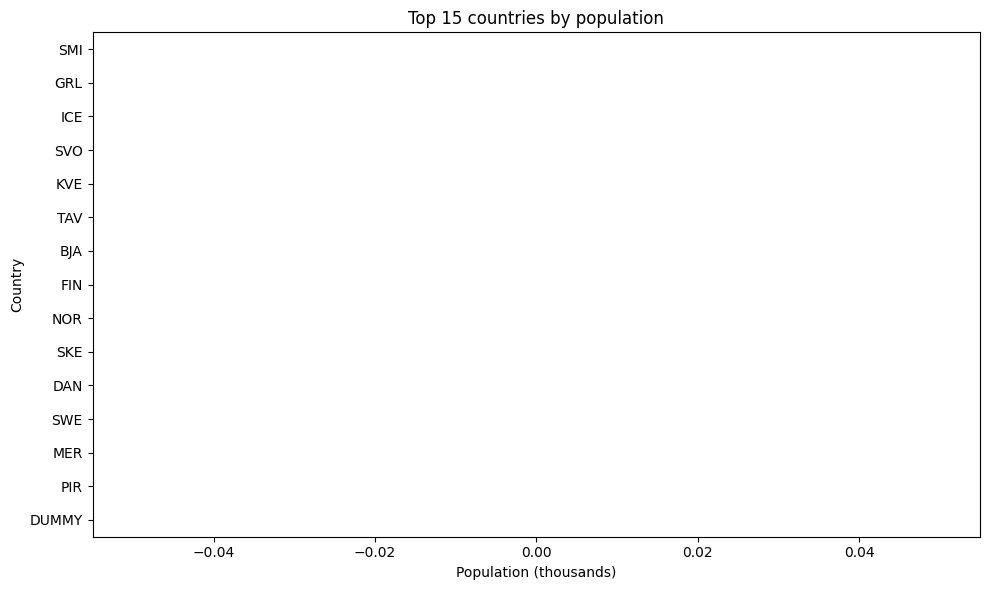

In [6]:
import matplotlib.pyplot as plt

top = df_countries.nlargest(15, "population")
ax = top.plot.barh(x="name", y="population", legend=False, figsize=(10, 6))
ax.set_xlabel("Population (thousands)")
ax.set_ylabel("Country")
plt.title("Top 15 countries by population")
plt.tight_layout()
plt.show()